# AOD ↔ PM2.5 Validation — Analysis (Step D)

Empirical validation of MODIS MAIAC AOD (`Optical_Depth_055`, the engine's Air-pillar
column-aerosol indicator) as a proxy for **surface** PM2.5, across 5 source-type regimes,
23 locations co-located with OpenAQ ground stations, window **2025-11-01 → 2026-04-30**.

AOD is sampled at each station's **exact coordinates** (1 km ≈ one MAIAC pixel); PM2.5 is the
OpenAQ daily aggregate at the same station. `aod_scaled` = raw MAIAC DN × 0.001 (physical AOD);
the engine carries the raw DN (`scale_factor=1.0`), which is scale-invariant for its z-score.

Reads `aod_pm25_validation.csv` (per-location) and `aod_pm25_daily.csv` (long daily), both from
`extract.py`. Analysis only — no engine code, thresholds, or seeds are touched.

In [1]:
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
REGIMES = ["industrial", "coal", "biomass", "dust", "clean"]
RCOLOR = {"industrial":"#d62728","coal":"#7f4f24","biomass":"#ff7f0e",
          "dust":"#bcbd22","clean":"#1f77b4"}

df = pd.read_csv("aod_pm25_validation.csv")
daily = pd.read_csv("aod_pm25_daily.csv")
daily["date"] = pd.to_datetime(daily["date"])
df["regime"] = pd.Categorical(df["regime"], REGIMES, ordered=True)
df = df.sort_values(["regime","location"]).reset_index(drop=True)
results = {}   # collected for the writeup
df[["location","regime","pm25_mean_ugm3","aod_mean_scaled","aod_n_days",
    "engine_z","engine_severity"]]

,location,regime,pm25_mean_ugm3,aod_mean_scaled,aod_n_days,engine_z,engine_severity
0,"Beijing, CN",industrial,37.62,0.3042,117,-0.206891,Normal
1,"Kolkata, IN",industrial,76.75,0.7648,109,0.616333,Normal
2,"Lagos, NG",industrial,14.44,0.5241,16,1.350325,Concern
3,"Mexico City, MX",industrial,25.28,0.2120,116,1.066996,Concern
4,"Katowice (Silesia), PL",coal,43.97,0.0816,32,-0.308982,Normal
5,"Korba, IN",coal,31.21,0.5472,147,0.030693,Normal
6,"Nagpur (Koradi), IN",coal,68.55,0.6002,134,1.185011,Concern
7,"Ostrava, CZ",coal,24.18,0.0902,33,-0.273889,Normal
8,"Pittsburgh PA, US",coal,7.37,0.0939,33,1.013730,Concern
9,"Abuja, NG",biomass,46.63,0.4430,63,-0.050430,Normal


## §3a — Scatter: AOD mean vs PM2.5 mean, coloured by regime

The expected pattern is **stratified clusters, not a single line**. Dust should sit lower-PM2.5
for a given AOD (elevated dust column); industrial should sit higher-PM2.5 for a given AOD.

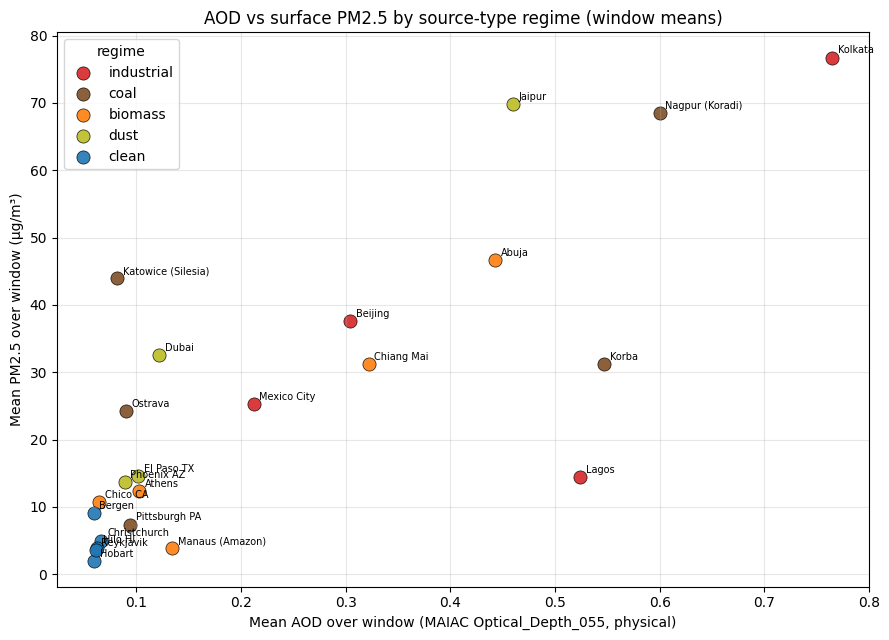

In [2]:
fig, ax = plt.subplots(figsize=(9,6.5))
for reg in REGIMES:
    s = df[df.regime==reg]
    ax.scatter(s.aod_mean_scaled, s.pm25_mean_ugm3, s=90, c=RCOLOR[reg],
               label=reg, edgecolor="k", linewidth=0.5, alpha=0.9)
for _,r in df.iterrows():
    ax.annotate(r.location.split(",")[0], (r.aod_mean_scaled, r.pm25_mean_ugm3),
                fontsize=7, xytext=(4,3), textcoords="offset points")
ax.set_xlabel("Mean AOD over window (MAIAC Optical_Depth_055, physical)")
ax.set_ylabel("Mean PM2.5 over window (µg/m³)")
ax.set_title("AOD vs surface PM2.5 by source-type regime (window means)")
ax.legend(title="regime"); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("aod_pm25_fig_scatter.png", dpi=130)
plt.show()

## §3b — Correlations: overall (pooled) and per-regime

The brief calls for an overall correlation **explicitly flagged as misleading** — regime structure
dominates — plus per-regime Pearson + Spearman. Per-regime n is small (4–5 sites), so per-regime
coefficients are indicative, not inferential; n and p are reported alongside.

In [3]:
def corr(x, y):
    x, y = np.asarray(x,float), np.asarray(y,float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: return (np.nan, np.nan, np.nan, int(m.sum()))
    pr,pp = stats.pearsonr(x[m], y[m]); sr,sp = stats.spearmanr(x[m], y[m])
    return (pr, pp, sr, int(m.sum()))

pr,pp,sr,n = corr(df.aod_mean_scaled, df.pm25_mean_ugm3)
print(f"OVERALL (pooled, n={n}) — MISLEADING by design (regime structure dominates):")
print(f"  Pearson r={pr:.2f} (p={pp:.3f})   Spearman rho={sr:.2f}")
results["overall"] = {"pearson_r":round(pr,2),"pearson_p":round(pp,3),
                      "spearman_rho":round(sr,2),"n":n}

rows=[]
for reg in REGIMES:
    s=df[df.regime==reg]
    pr,pp,sr,n=corr(s.aod_mean_scaled, s.pm25_mean_ugm3)
    rows.append({"regime":reg,"n":n,"pearson_r":round(pr,2),"pearson_p":round(pp,3),
                 "spearman_rho":round(sr,2),
                 "AOD_mean":round(s.aod_mean_scaled.mean(),3),
                 "PM25_mean":round(s.pm25_mean_ugm3.mean(),1)})
per_regime=pd.DataFrame(rows); results["per_regime_window_corr"]=rows
per_regime

OVERALL (pooled, n=23) — MISLEADING by design (regime structure dominates):
  Pearson r=0.78 (p=0.000)   Spearman rho=0.75


,regime,n,pearson_r,pearson_p,spearman_rho,AOD_mean,PM25_mean
0,industrial,4,0.67,0.327,0.4,0.451,38.5
1,coal,5,0.62,0.264,0.3,0.283,35.1
2,biomass,5,0.95,0.013,0.7,0.213,20.9
3,dust,4,0.96,0.036,1.0,0.193,32.7
4,clean,5,-0.11,0.860,0.0,0.062,4.7


## §3c — AOD-per-unit-PM2.5 ratio by regime

The structural signature of the regimes: dust puts more aerosol in the *column* per µg/m³ of
*surface* PM2.5 (elevated dust), so a higher AOD/PM2.5 ratio; industrial/combustion is more
surface-weighted (lower ratio).

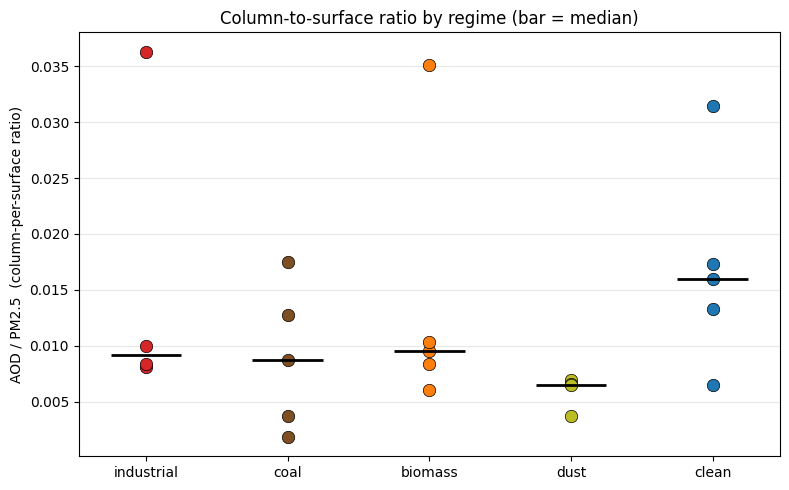

,mean,median,count
regime,,,
industrial,0.0157,0.0092,4
coal,0.0089,0.0088,5
biomass,0.0139,0.0095,5
dust,0.0059,0.0065,4
clean,0.0169,0.0159,5


In [4]:
df["aod_per_pm25"] = df.aod_mean_scaled / df.pm25_mean_ugm3
ratio = df.groupby("regime", observed=True)["aod_per_pm25"].agg(["mean","median","count"]).round(4)
results["aod_per_pm25_ratio"] = {r:round(float(v),4) for r,v in ratio["median"].items()}

fig, ax = plt.subplots(figsize=(8,5))
for i,reg in enumerate(REGIMES):
    v = df[df.regime==reg]["aod_per_pm25"].values
    ax.scatter(np.full_like(v, i, dtype=float), v, c=RCOLOR[reg], s=80,
               edgecolor="k", linewidth=0.5, zorder=3)
    ax.hlines(np.median(v), i-0.25, i+0.25, color="k", lw=2, zorder=4)
ax.set_xticks(range(len(REGIMES))); ax.set_xticklabels(REGIMES)
ax.set_ylabel("AOD / PM2.5  (column-per-surface ratio)")
ax.set_title("Column-to-surface ratio by regime (bar = median)")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout(); fig.savefig("aod_pm25_fig_ratio.png", dpi=130)
plt.show(); ratio

## §4 — Per-location daily coupling (the proxy-strength metric)

The window mean hides the day-to-day question that matters for screening: *when AOD moves, does
surface PM2.5 move with it at this location?* For each location we align AOD and PM2.5 on shared
days and compute the day-by-day Pearson r. Locations with **< 15 paired days** (cloud-limited
retrieval) are reported but flagged insufficient.

In [5]:
MIN_PAIRS = 15
rows=[]
for _,r in df.iterrows():
    d = daily[daily.loc_index==r.loc_index].dropna(subset=["pm25_ugm3","aod_scaled"])
    n=len(d)
    if n>=3:
        pr,pp = stats.pearsonr(d.pm25_ugm3, d.aod_scaled)
        sr,_  = stats.spearmanr(d.pm25_ugm3, d.aod_scaled)
    else:
        pr=pp=sr=np.nan
    rows.append({"location":r.location,"regime":r.regime,"paired_days":n,
                 "daily_pearson_r":round(pr,2) if np.isfinite(pr) else None,
                 "daily_p":round(pp,3) if np.isfinite(pp) else None,
                 "sufficient": n>=MIN_PAIRS})
daily_corr=pd.DataFrame(rows).sort_values(["regime","daily_pearson_r"],
                                          ascending=[True,False]).reset_index(drop=True)
results["daily_corr"]=daily_corr.to_dict("records")
ok=daily_corr[daily_corr.sufficient].dropna(subset=["daily_pearson_r"])
results["daily_corr_summary"]={
    "n_sufficient":int(ok.shape[0]),
    "median_r":round(float(ok.daily_pearson_r.median()),2),
    "frac_r_above_0.5":round(float((ok.daily_pearson_r>0.5).mean()),2),
    "frac_r_below_0.3":round(float((ok.daily_pearson_r<0.3).mean()),2)}
print("Sufficient-coverage locations:", results["daily_corr_summary"])
daily_corr

Sufficient-coverage locations: {'n_sufficient': 21, 'median_r': 0.23, 'frac_r_above_0.5': 0.14, 'frac_r_below_0.3': 0.57}


,location,regime,paired_days,daily_pearson_r,daily_p,sufficient
0,"Chiang Mai, TH",biomass,119,0.87,0.000,True
1,"Manaus (Amazon), BR",biomass,15,0.62,0.014,True
2,"Athens, GR",biomass,73,0.23,0.052,True
3,"Chico CA, US",biomass,76,-0.02,0.837,True
4,"Abuja, NG",biomass,51,-0.04,0.789,True
5,"Hilo HI, US",clean,17,0.57,0.017,True
6,"Christchurch, NZ",clean,67,0.30,0.015,True
7,"Hobart, AU",clean,51,0.09,0.546,True
8,"Bergen, NO",clean,21,-0.11,0.648,True
9,"Reykjavik, IS",clean,2,NaN,NaN,False


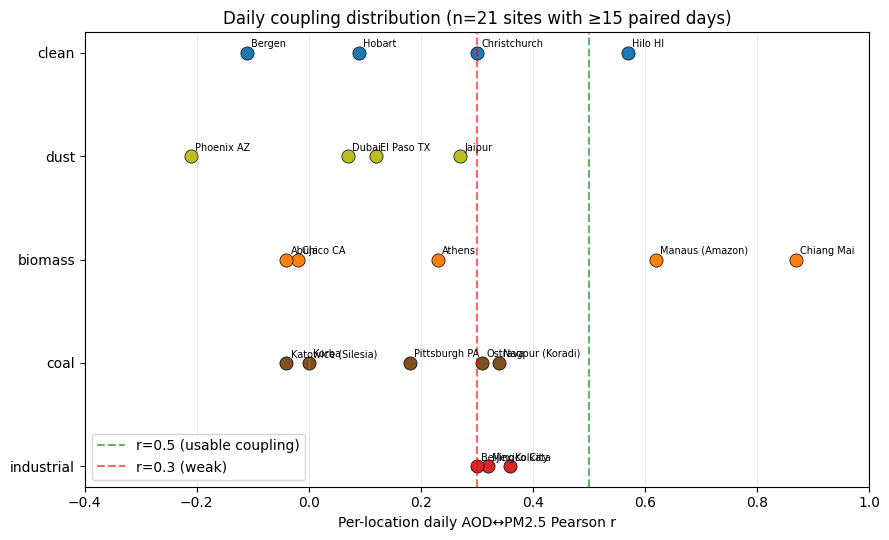

In [6]:
fig, ax = plt.subplots(figsize=(9,5.5))
for reg in REGIMES:
    s=ok[ok.regime==reg]
    ax.scatter(s.daily_pearson_r, [reg]*len(s), c=RCOLOR[reg], s=90,
               edgecolor="k", linewidth=0.5)
    for _,rr in s.iterrows():
        ax.annotate(rr.location.split(",")[0],(rr.daily_pearson_r,reg),
                    fontsize=7,xytext=(3,4),textcoords="offset points")
ax.axvline(0.5,ls="--",c="green",alpha=0.6,label="r=0.5 (usable coupling)")
ax.axvline(0.3,ls="--",c="red",alpha=0.6,label="r=0.3 (weak)")
ax.set_xlabel("Per-location daily AOD↔PM2.5 Pearson r"); ax.set_xlim(-0.4,1)
ax.set_title(f"Daily coupling distribution (n={ok.shape[0]} sites with ≥{MIN_PAIRS} paired days)")
ax.legend(); ax.grid(alpha=0.3, axis="x")
fig.tight_layout(); fig.savefig("aod_pm25_fig_daily_coupling.png", dpi=130)
plt.show()

## §5a — Failure mode A: AOD fires high, surface PM2.5 does not

The canonical dust failure mode — an elevated dust column inflates AOD while surface PM2.5 stays
moderate. Ranked by AOD-per-PM2.5 (high column relative to surface); the **engine** column shows
what its z-score band emits at each site.

In [7]:
show=["location","regime","aod_mean_scaled","pm25_mean_ugm3","aod_per_pm25",
       "engine_z","engine_severity","aod_n_days"]
high_col = df.sort_values("aod_per_pm25", ascending=False)[show].head(8).round(3)
results["aod_high_pm25_low"]=high_col.to_dict("records")
high_col

,location,regime,aod_mean_scaled,pm25_mean_ugm3,aod_per_pm25,engine_z,engine_severity,aod_n_days
2,"Lagos, NG",industrial,0.524,14.44,0.036,1.350,Concern,16
13,"Manaus (Amazon), BR",biomass,0.134,3.82,0.035,1.928,Concern,15
21,"Hobart, AU",clean,0.060,1.90,0.031,0.592,Normal,51
5,"Korba, IN",coal,0.547,31.21,0.018,0.031,Normal,147
22,"Reykjavik, IS",clean,0.061,3.53,0.017,0.675,Normal,2
20,"Hilo HI, US",clean,0.063,3.94,0.016,1.254,Concern,18
19,"Christchurch, NZ",clean,0.067,5.00,0.013,0.433,Normal,69
8,"Pittsburgh PA, US",coal,0.094,7.37,0.013,1.014,Concern,33


## §5b — Failure mode B: surface PM2.5 high, AOD does not register

The opposite — shallow winter boundary-layer / local combustion loads the surface while the column
stays thin (and cloud limits retrieval). Ranked by low AOD-per-PM2.5 among the higher-PM2.5 sites.

In [8]:
low_col = df[df.pm25_mean_ugm3>20].sort_values("aod_per_pm25")[show].head(8).round(3)
results["pm25_high_aod_low"]=low_col.to_dict("records")
low_col

,location,regime,aod_mean_scaled,pm25_mean_ugm3,aod_per_pm25,engine_z,engine_severity,aod_n_days
4,"Katowice (Silesia), PL",coal,0.082,43.97,0.002,-0.309,Normal,32
7,"Ostrava, CZ",coal,0.090,24.18,0.004,-0.274,Normal,33
14,"Dubai, AE",dust,0.122,32.59,0.004,-0.037,Normal,125
16,"Jaipur, IN",dust,0.459,69.85,0.007,-0.154,Normal,120
0,"Beijing, CN",industrial,0.304,37.62,0.008,-0.207,Normal,117
3,"Mexico City, MX",industrial,0.212,25.28,0.008,1.067,Concern,116
6,"Nagpur (Koradi), IN",coal,0.600,68.55,0.009,1.185,Concern,134
9,"Abuja, NG",biomass,0.443,46.63,0.010,-0.050,Normal,63


## §6 — Engine severity vs absolute AOD vs surface PM2.5

The engine's Air-pillar severity is a **local anomaly z-score** (site vs background ring), not an
absolute-AOD band. So the highest-AOD sites can read **Normal** (uniformly hazy region → no local
contrast), and a moderate-AOD site in clean surroundings can read **Concern/High**. This table makes
that explicit and is the core input to the §7 calibration recommendation.

In [9]:
eng = df[["location","regime","aod_mean_scaled","pm25_mean_ugm3","engine_site_dn",
           "engine_background_dn","engine_z","engine_confidence","engine_severity"]].round(3)
eng = eng.sort_values("aod_mean_scaled", ascending=False).reset_index(drop=True)
results["engine_table"]=eng.to_dict("records")
df["aod_q"]=pd.qcut(df.aod_mean_scaled,4,labels=["Q1-low","Q2","Q3","Q4-high"])
ct = pd.crosstab(df.aod_q, df.engine_severity)
results["engine_band_vs_aod_quartile"]=ct.to_dict()
print("Engine severity band vs absolute-AOD quartile:"); print(ct)
eng

Engine severity band vs absolute-AOD quartile:
engine_severity  Concern  Normal
aod_q                           
Q1-low                 1       5
Q2                     3       3
Q3                     2       3
Q4-high                2       4


,location,regime,aod_mean_scaled,pm25_mean_ugm3,engine_site_dn,engine_background_dn,engine_z,engine_confidence,engine_severity
0,"Kolkata, IN",industrial,0.765,76.75,724.351,708.476,0.616,0.819,Normal
1,"Nagpur (Koradi), IN",coal,0.600,68.55,601.952,570.480,1.185,0.827,Concern
2,"Korba, IN",coal,0.547,31.21,532.528,530.911,0.031,0.816,Normal
3,"Lagos, NG",industrial,0.524,14.44,593.475,484.190,1.350,0.701,Concern
4,"Jaipur, IN",dust,0.459,69.85,429.076,433.561,-0.154,0.800,Normal
5,"Abuja, NG",biomass,0.443,46.63,486.221,489.143,-0.050,0.780,Normal
6,"Chiang Mai, TH",biomass,0.322,31.17,306.622,307.478,-0.043,0.793,Normal
7,"Beijing, CN",industrial,0.304,37.62,269.654,273.490,-0.207,0.814,Normal
8,"Mexico City, MX",industrial,0.212,25.28,211.949,183.470,1.067,0.847,Concern
9,"Manaus (Amazon), BR",biomass,0.134,3.82,145.373,94.916,1.928,0.746,Concern


In [10]:
# Retrieval-coverage summary (the §6 cloud/latitude caveat, quantified)
cov = df.groupby("regime", observed=True)["aod_n_days"].agg(["min","median","max"]).astype(int)
results["aod_coverage_by_regime"]={k:{kk:int(vv) for kk,vv in v.items()} for k,v in cov.to_dict("index").items()}
results["worst_coverage"]=df.nsmallest(5,"aod_n_days")[["location","aod_n_days"]].to_dict("records")
print("AOD valid-retrieval days per regime (of 181):"); print(cov)
print("\nSparsest:", results["worst_coverage"])
with open("aod_pm25_analysis_results.json","w") as f: json.dump(results,f,indent=2,default=str)
print("\nwrote aod_pm25_analysis_results.json")

AOD valid-retrieval days per regime (of 181):
            min  median  max
regime                      
industrial   16     112  117
coal         32      33  147
biomass      15      76  120
dust        120     123  128
clean         2      23   69

Sparsest: [{'location': 'Reykjavik, IS', 'aod_n_days': 2}, {'location': 'Manaus (Amazon), BR', 'aod_n_days': 15}, {'location': 'Lagos, NG', 'aod_n_days': 16}, {'location': 'Hilo HI, US', 'aod_n_days': 18}, {'location': 'Bergen, NO', 'aod_n_days': 23}]

wrote aod_pm25_analysis_results.json
